# Van der Veen damage-rate drop-in

This notebook implements the Freund-style rate closure in the accompanying technical note. The host ice-sheet model supplies the surface and basal mode-I stress-intensity factors. The function returns the surface, basal, and total damage rates.

The calculation assumes:

- $H>0$, $K_{\mathrm{Ic}}>0$, and $v_s,v_b\geq0$.
- $K_{\mathrm{I}}^{s}$ and $K_{\mathrm{I}}^{b}$ are the stationary-crack stress-intensity factors at the current crack lengths.
- Existing cracks grow without healing or nucleation.
- $D=D_s+D_b=1$ is a terminal full-thickness fracture.
- All inputs use SI units, so the returned rates have units of $\mathrm{s^{-1}}$.
- The host discretization handles advection; this function supplies the source in the material derivative.

The forcing example below is illustrative. It is not an observation or a calculation of the van der Veen stress-intensity factors.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## Drop-in rate function

For $q=K_{\mathrm{I}}/K_{\mathrm{Ic}}$, the Freund factor is

$$
\mathcal F(q)=\begin{cases}0,&q<1,\\1-q^{-2},&q\geq1.\end{cases}
$$

The two functions in the next cell are the only code needed by the host model. They work on scalars or NumPy arrays.

In [2]:
def freund_factor(q):
    """Freund kinetic factor for q = K_I / K_Ic."""
    q = np.asarray(q, dtype=float)
    active = q >= 1.0
    inverse_q = np.zeros_like(q)
    np.divide(1.0, q, out=inverse_q, where=active)
    return np.where(active, 1.0 - inverse_q**2, 0.0)


def vdv_damage_rate(D_s, D_b, H, K_I_s, K_I_b, K_Ic, v_s, v_b):
    """Return dD_s/dt, dD_b/dt, and dD/dt in s^-1."""
    intact = np.asarray(D_s) + np.asarray(D_b) < 1.0
    dD_s_dt = np.where(intact, (v_s / H) * freund_factor(K_I_s / K_Ic), 0.0)
    dD_b_dt = np.where(intact, (v_b / H) * freund_factor(K_I_b / K_Ic), 0.0)
    return dD_s_dt, dD_b_dt, dD_s_dt + dD_b_dt

In [3]:
rates = vdv_damage_rate(
    D_s=0.10, D_b=0.05, H=1000.0,
    K_I_s=120e3, K_I_b=90e3, K_Ic=100e3,
    v_s=0.02, v_b=0.01,
)
print("dD_s/dt = {:.3e} s^-1".format(rates[0]))
print("dD_b/dt = {:.3e} s^-1".format(rates[1]))
print("dD/dt   = {:.3e} s^-1".format(rates[2]))

dD_s/dt = 6.111e-06 s^-1
dD_b/dt = 0.000e+00 s^-1
dD/dt   = 6.111e-06 s^-1


The surface crack grows because $K_{\mathrm{I}}^{s}>K_{\mathrm{Ic}}$. The basal crack arrests because $K_{\mathrm{I}}^{b}<K_{\mathrm{Ic}}$.

## Figure 1: kinetic closure

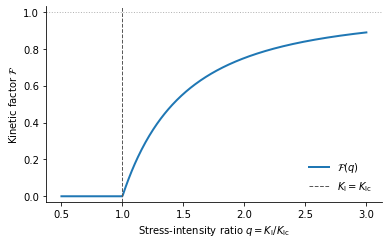

In [4]:
q = np.linspace(0.5, 3.0, 400)

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(q, freund_factor(q), linewidth=2, label=r"$\mathcal{F}(q)$")
ax.axvline(1.0, color="0.35", linestyle="--", linewidth=1, label=r"$K_{\mathrm{I}}=K_{\mathrm{Ic}}$")
ax.axhline(1.0, color="0.7", linestyle=":", linewidth=1)
ax.set(xlabel=r"Stress-intensity ratio $q=K_{\mathrm{I}}/K_{\mathrm{Ic}}$",
       ylabel=r"Kinetic factor $\mathcal{F}$", ylim=(-0.03, 1.03))
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

**Figure 1.** The rate is zero below the toughness threshold and approaches the limiting crack-speed scale as $K_{\mathrm{I}}/K_{\mathrm{Ic}}$ increases.

## Figure 2: one-column time integration

This example prescribes two smooth stress-intensity pulses and advances $D_s$ and $D_b$ with a 60 s forward-Euler step. The chosen speed scales are illustrative effective values, not measurements of ice fracture speed.

In [5]:
seconds_per_hour = 3600.0
dt = 60.0
time = np.arange(0.0, 12.0 * seconds_per_hour + dt, dt)
time_hours = time / seconds_per_hour

q_s = 0.85 + 0.65 * np.exp(-((time_hours - 4.0) / 1.5)**2)
q_b = 0.92 + 0.25 * np.exp(-((time_hours - 8.0) / 2.0)**2)

H = 1000.0
K_Ic = 100e3
v_s, v_b = 0.02, 0.01
D_s = np.zeros_like(time)
D_b = np.zeros_like(time)
D_s[0], D_b[0] = 0.08, 0.04

for n in range(time.size - 1):
    dD_s_dt, dD_b_dt, _ = vdv_damage_rate(
        D_s[n], D_b[n], H, q_s[n] * K_Ic, q_b[n] * K_Ic, K_Ic, v_s, v_b
    )
    D_s[n + 1] = D_s[n] + dt * dD_s_dt
    D_b[n + 1] = D_b[n] + dt * dD_b_dt

D = D_s + D_b
print("Final damage: D_s = {:.3f}, D_b = {:.3f}, D = {:.3f}".format(D_s[-1], D_b[-1], D[-1]))

Final damage: D_s = 0.175, D_b = 0.066, D = 0.241


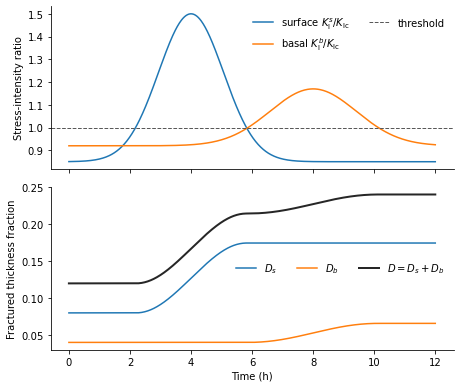

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(6.5, 5.5), sharex=True)

axes[0].plot(time_hours, q_s, label=r"surface $K_{\mathrm{I}}^{s}/K_{\mathrm{Ic}}$")
axes[0].plot(time_hours, q_b, label=r"basal $K_{\mathrm{I}}^{b}/K_{\mathrm{Ic}}$")
axes[0].axhline(1.0, color="0.35", linestyle="--", linewidth=1, label="threshold")
axes[0].set_ylabel("Stress-intensity ratio")
axes[0].legend(frameon=False, ncol=2)

axes[1].plot(time_hours, D_s, label=r"$D_s$")
axes[1].plot(time_hours, D_b, label=r"$D_b$")
axes[1].plot(time_hours, D, color="0.15", linewidth=2, label=r"$D=D_s+D_b$")
axes[1].set(xlabel="Time (h)", ylabel="Fractured thickness fraction")
axes[1].legend(frameon=False, ncol=3)

fig.tight_layout()
plt.show()

**Figure 2.** Prescribed surface and basal stress-intensity ratios (top) and the resulting fractured thickness fractions (bottom). Each component grows only while its ratio exceeds one. The total rate is the sum of the two component rates.

## Handoff notes

Inside an existing model time step, the call is:

```python
dD_s_dt, dD_b_dt, dD_dt = vdv_damage_rate(
    D_s, D_b, H, K_I_s, K_I_b, K_Ic, v_s, v_b
)
D_s = D_s + dt_seconds * dD_s_dt
D_b = D_b + dt_seconds * dD_b_dt
failed = D_s + D_b >= 1.0
```

The third return value can replace a scalar damage source. Retain $D_s$ and $D_b$ as separate states when the surface and basal stress-intensity factors depend on their respective crack depths.

If the host model uses years, multiply the returned rates by $365.25\times24\times3600$ before applying a time step in years. A Rayleigh-speed choice for $v_j$ gives an $H/v_j$ timescale of order seconds, which is much shorter than a usual ice-sheet time step. Such a calculation should be treated as a fracture event or integrated with an appropriately short substep.

For active cracks, the model predicts $H(\mathrm{D}D_j/\mathrm{D}t)/\mathcal F(K_{\mathrm{I}}^j/K_{\mathrm{Ic}})=v_j$. Time-resolved crevasse-depth measurements could therefore test the assumed closure.